# Information Theory for Support-Ticket Triage

## The situation

Your company runs a customer-support desk. Every incoming ticket is passed to an
**AI classifier** that sorts it into one of six categories:

`billing` · `technical_issue` · `refund_request` · `sales_question` · `account_access` · `urgent_complaint`

The model has been running for a year and used to work well. Over the **last three
months its performance has quietly declined**, and nobody is quite sure why. You are the
data analysts asked to find out.

## What you have to work with

You **do not** have the model itself — treat it as a black box (it may not even exist
anymore). What you *do* have, for every ticket, is:

- the model's **predicted probability** for each of the six categories (columns `p_*`),
- the **true category** the ticket turned out to belong to,
- the ticket's **features** (plan, region, product area, message length, waiting time, …),
- a `period` label: **`historical`** (the large dataset the model was calibrated on) and
  **`current`** (the last three months, where things went wrong).

## The tool for the job: information theory

Every question in this notebook is really a question about *probability distributions* —
how peaked, how wrong, how shifted, how informative. Information theory gives us one
precise number for each:

1. **Entropy** — how *unsure* is the model on a given ticket?
2. **Cross-entropy** — how *wrong* are the confident predictions?
3. **KL divergence** — has the *mix of tickets* shifted since the model was trained?
4. **Mutual information** — which *features* now carry the signal the model is missing?

You will implement each metric yourself and use it to move one step further in the
investigation.

In [1]:
#@title 🗺️ Roadmap: the four lenses of this investigation { display-mode: "form" }
from IPython.display import HTML, display

def _roadmap():
    steps = [("🎯", "Entropy", "how unsure is the model?", "route the shaky tickets to humans"),
             ("📉", "Cross-entropy", "how wrong are the rest?", "find the costly mistakes"),
             ("🌊", "KL divergence", "did the ticket mix shift?", "locate the shift, per category & product"),
             ("🔗", "Mutual information", "which feature now matters?", "explain what the update changed")]
    grad = ["#667eea", "#8a6fe0", "#b06fd0", "#db6fa9"]
    blocks = ""
    for (ic, t, q, d), g in zip(steps, grad):
        blocks += (f'<div class="rm-step"><div class="rm-ic" style="background:linear-gradient(135deg,{g},{g}cc)">{ic}</div>'
                   f'<div class="rm-t">{t}</div><div class="rm-q">{q}</div><div class="rm-d">{d}</div></div>'
                   '<div class="rm-ar">➜</div>')
    blocks = blocks.rsplit('<div class="rm-ar">➜</div>', 1)[0]
    display(HTML(f'''
<style>
.rm{{font-family:system-ui,Segoe UI,Roboto,sans-serif;background:linear-gradient(135deg,#f6f8ff,#fbf5ff);
    border-radius:18px;padding:20px 16px;margin:8px 0;border:1px solid #ecebff}}
.rm-h{{font-size:20px;font-weight:800;color:#3b2d6b;margin:0 0 4px}}
.rm-s{{font-size:12px;color:#6b6685;margin:0 0 16px}}
.rm-row{{display:flex;align-items:stretch;flex-wrap:wrap;gap:0}}
.rm-step{{flex:1 1 150px;min-width:150px;text-align:center;padding:0 6px}}
.rm-ic{{width:52px;height:52px;border-radius:50%;margin:0 auto 8px;display:flex;align-items:center;
       justify-content:center;font-size:23px;color:#fff;box-shadow:0 6px 14px rgba(102,126,234,.35)}}
.rm-t{{font-weight:800;font-size:13.5px;color:#2c2350}}
.rm-q{{font-size:11px;color:#6b6685;margin-top:3px;font-style:italic;line-height:1.3}}
.rm-d{{font-size:10.5px;color:#8b86a6;margin-top:5px;line-height:1.3}}
.rm-ar{{display:flex;align-items:center;font-size:18px;color:#b9a9e6;flex:0 0 14px}}
</style>
<div class="rm">
  <div class="rm-h">🗺️ Four questions, four metrics</div>
  <div class="rm-s">Each step answers one question about the model and hands the investigation to the next.</div>
  <div class="rm-row">{blocks}</div>
</div>'''))

_roadmap()

In [2]:
#@title Setup { display-mode: "form" }
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from IPython.display import HTML, display

plt.rcParams['figure.dpi'] = 110
PURPLE, PURPLE2 = '#667eea', '#764ba2'
GREEN, RED, AMBER = '#39b36a', '#e0796d', '#e0a23c'
RANDOM_STATE = 0

In [3]:
#@title Define the dataset builder (offline fallback) { display-mode: "form" }
# The data normally comes from the course repo (next cell). This builder reproduces the
# EXACT same dataset from scratch, so the notebook still runs if the repo is unreachable.
CATEGORIES = ['billing', 'technical_issue', 'refund_request',
              'sales_question', 'account_access', 'urgent_complaint']
PRODUCTS = ['payments', 'analytics', 'mobile_app', 'search', 'notifications', 'api']
BILLING, TECH, REFUND, SALES, ACCOUNT, URGENT = range(6)
_AFF = {'payments':[1.4,-0.2,1.0,-0.3,-0.2,0.1], 'analytics':[-0.3,0.8,-0.3,1.0,0.0,0.0],
        'mobile_app':[-0.3,1.2,-0.2,-0.2,0.9,0.1], 'search':[-0.2,1.1,-0.3,0.2,0.1,0.0],
        'notifications':[-0.2,0.7,-0.2,0.0,1.0,0.1], 'api':[0.0,1.0,-0.2,0.8,0.2,0.0]}
_INT = np.array([0.30, 0.50, -0.10, 0.0, 0.0, -1.25])

def _z(a): a = a.astype(float); return (a - a.mean()) / (a.std() + 1e-9)
def _softmax(L): L = L - L.max(1, keepdims=True); e = np.exp(L); return e / e.sum(1, keepdims=True)
def _sample(P, rng): c = P.cumsum(1); r = rng.random((P.shape[0], 1)); return (r < c).argmax(1)

def build_tickets(n_hist=30000, n_cur=15000, seed=42, sharpness=2.8):
    rng = np.random.default_rng(seed); n = n_hist + n_cur
    is_cur = np.zeros(n, bool); is_cur[n_hist:] = True
    month = np.empty(n, int)
    month[:n_hist] = rng.integers(-11, 1, n_hist); month[n_hist:] = rng.integers(1, 4, n_cur)
    plan = rng.choice(['free','basic','pro','enterprise'], n, p=[.35,.3,.25,.1])
    region = rng.choice(['NAM','EU','APAC','LATAM'], n, p=[.35,.3,.2,.15])
    product = rng.choice(PRODUCTS, n, p=[.20,.15,.22,.15,.13,.15])
    msg = np.clip(rng.lognormal(5.0, 0.6, n), 20, 4000).round().astype(int)
    wait = np.clip(rng.exponential(8.0, n), 0.1, 240).round(2)
    prev = rng.poisson(1.2, n)
    weekend = (rng.random(n) < 0.28).astype(int)
    value = np.clip(rng.normal(50, 18, n), 0, 100).round(1)
    zlen, zwait, zprev = _z(np.log(msg)), _z(np.log1p(wait)), _z(prev)
    ent = (plan == 'enterprise').astype(float); free_ = (plan == 'free').astype(float)
    latam = (region == 'LATAM').astype(float)
    L = np.tile(_INT, (n, 1)).astype(float)
    for p, a in _AFF.items(): L[product == p] += np.array(a)
    L[:, URGENT] += 0.30*zlen + 0.30*zwait + 0.25*zprev + 0.20*weekend + 0.15*latam
    L[:, TECH] += 0.35*zlen
    L[:, SALES] += -0.30*zlen + 0.70*ent + 0.30*_z(value)
    L[:, ACCOUNT] += 0.50*ent
    L[:, BILLING] += 0.50*free_
    L[:, REFUND] += 0.40*zprev
    L_model = L * sharpness                          # frozen model = sharpened historical
    L[is_cur, URGENT] += 0.245                        # small global drift toward urgent
    mm = is_cur & (product == 'mobile_app')          # the mobile_app update (concept shift)
    L[mm, URGENT] += 1.19*zwait[mm] + 0.63*zprev[mm] + 1.47
    L[mm, TECH] -= 0.7*zwait[mm]
    pm = is_cur & (product == 'payments')            # a milder payments update
    L[pm, REFUND] += 0.63*zlen[pm] + 0.42
    L *= sharpness                                    # sharpen true logits (hist + shift) together
    tp, mp = _softmax(L), _softmax(L_model)
    true, pred = _sample(tp, rng), mp.argmax(1)
    d = pd.DataFrame({'ticket_id': np.arange(1, n+1),
        'period': np.where(is_cur, 'current', 'historical'), 'month': month,
        'customer_plan': plan, 'region': region, 'product_area': product,
        'message_length': msg, 'waiting_time_hours': wait,
        'previous_tickets_30d': prev, 'submitted_weekend': weekend,
        'customer_value_score': value})
    for i, c in enumerate(CATEGORIES): d['p_' + c] = mp[:, i].round(5)
    d['predicted_category'] = [CATEGORIES[i] for i in pred]
    d['true_category'] = [CATEGORIES[i] for i in true]
    return d.sample(frac=1.0, random_state=seed).reset_index(drop=True)

CATEGORIES  # (defined; the data is loaded in the next cell)

['billing',
 'technical_issue',
 'refund_request',
 'sales_question',
 'account_access',
 'urgent_complaint']

In [4]:
#@title Load the support-ticket data (from the public course repo) { display-mode: "form" }
# The data lives in the PUBLIC course repo, so NO GitHub token is needed — we fetch
# tickets.csv directly over HTTPS. If the download fails (e.g. no internet), we fall
# back to building an equivalent dataset offline with build_tickets().
import os, urllib.request

DATA = 'tickets.csv'
URL  = 'https://raw.githubusercontent.com/eth-fdd-fs26/FDD-WE1-public/main/tickets.csv'

def _download_data():
    try:
        urllib.request.urlretrieve(URL, DATA)
        return True
    except Exception as e:
        print('could not download from repo:', e)
        return False

if not os.path.exists(DATA):
    _download_data()

if os.path.exists(DATA):
    df = pd.read_csv(DATA)
    print(f'loaded {DATA} from the course repo   ({len(df)} tickets)')
else:
    df = build_tickets()
    print(f'repo file unavailable -> built the dataset inline   ({len(df)} tickets)')

PCOLS = ['p_' + c for c in CATEGORIES]
hist = df[df.period == 'historical'].reset_index(drop=True)
cur = df[df.period == 'current'].reset_index(drop=True)
print('historical', len(hist), '| current', len(cur))
df[['period','product_area','waiting_time_hours','predicted_category','true_category'] + PCOLS[:3]].head(4)

loaded tickets.csv from the course repo   (45000 tickets)
historical 30000 | current 15000


,period,product_area,waiting_time_hours,predicted_category,true_category,p_billing,p_technical_issue,p_refund_request
0,current,api,0.83,technical_issue,sales_question,0.14611,0.74741,0.00547
1,historical,payments,3.56,billing,refund_request,0.79114,0.07279,0.13145
2,current,api,8.42,technical_issue,technical_issue,0.18568,0.41905,0.01938
3,historical,analytics,2.00,sales_question,sales_question,0.12705,0.31458,0.06470


Each row is one ticket. The six `p_*` columns are the **model's output** — they sum to 1
and represent its confidence in each category. `predicted_category` is simply the largest of
them (what the model would answer if forced to pick). `true_category` is what the ticket
actually was.

Throughout, we work mostly with the **`current`** slice (the troubled last three months) and
use **`historical`** as the reference baseline.

# Part 1 — Entropy: which tickets is the model unsure about?

The support team noticed something: the model always gives an answer, but sometimes the six
probabilities are almost **tied**. It picks the top one *greedily*, yet a `0.19` vs `0.18`
victory is basically a coin flip. Sometimes that guess is right; often it is not.

**The plan.** The team can afford to have humans hand-check the **15% of tickets the model is
least sure about**. But "least sure" needs a definition. A single number that turns a whole
probability vector into *how spread out it is* — that is exactly **entropy**.

$$H(p) = -\sum_{c} p_c \, \log p_c$$

A confident prediction (one class near 1) has **low** entropy. A flat, undecided prediction
(mass spread evenly) has **high** entropy — up to $\log 6 \approx 1.79$ nats for six classes.

In [5]:
#@title 🎲 Interactive: three examples, then generate your own { display-mode: "form" }
from IPython.display import HTML, display
display(HTML(r'''
<style>
.en{font-family:system-ui,Segoe UI,Roboto,sans-serif;background:linear-gradient(135deg,#f6f8ff,#fbf5ff);
    border:1px solid #ecebff;border-radius:18px;padding:18px;max-width:740px;color:#2c2350}
.en-h{font-size:18px;font-weight:800;color:#3b2d6b;margin:0 0 3px}
.en-s{font-size:12px;color:#6b6685;margin:0 0 14px;line-height:1.45}
.en-ex{display:flex;gap:11px;flex-wrap:wrap;margin-bottom:16px}
.en-card{flex:1 1 200px;background:#fff;border:1px solid #eceaf6;border-radius:13px;padding:11px 12px}
.en-tag{display:inline-block;font-size:10px;font-weight:800;border-radius:7px;padding:3px 9px;margin-bottom:8px}
.en-mini{display:flex;align-items:flex-end;justify-content:space-between;gap:6px;height:78px;padding:0 2px}
.en-col{flex:1;display:flex;flex-direction:column;align-items:center;justify-content:flex-end;height:100%}
.en-bar{width:56%;max-width:15px;border-radius:5px 5px 0 0;background:linear-gradient(180deg,#8a8ff0,#764ba2)}
.en-lab{font-size:8px;color:#a7a3bd;margin-top:5px;text-align:center;line-height:1}
.en-eh{font-size:12px;color:#3b2d6b;margin-top:8px;font-weight:700}
.en-eh b{font-size:15px}
.en-gen{background:#fff;border:1px solid #eceaf6;border-radius:13px;padding:14px}
.en-btn{cursor:pointer;border:none;border-radius:11px;padding:10px 16px;font-size:13px;font-weight:800;color:#fff;
    background:linear-gradient(135deg,#667eea,#764ba2);box-shadow:0 5px 13px rgba(118,75,162,.3)}
.en-btn:active{transform:translateY(1px)}
.en-bars{display:flex;align-items:flex-end;justify-content:space-between;gap:9px;height:120px;margin-top:14px;padding:0 2px}
.en-read{display:flex;align-items:center;gap:14px;margin-top:12px}
.en-num{font-size:26px;font-weight:800;color:#3b2d6b;font-variant-numeric:tabular-nums;min-width:150px}
.en-num span{font-size:12px;color:#8b86a6;font-weight:600}
.en-meter{flex:1;height:12px;border-radius:8px;background:linear-gradient(90deg,#39b36a,#e0a23c,#e0796d);position:relative}
.en-needle{position:absolute;top:-4px;width:3px;height:20px;background:#2c2350;border-radius:2px;transition:left .2s}
.en-verd{font-size:12.5px;font-weight:700;margin-top:11px;padding:8px 11px;border-radius:10px;text-align:center}
</style>
<div class="en">
  <div class="en-h">🎲 Entropy of a prediction</div>
  <div class="en-s">Here are three predictions over the six categories &mdash; <b>low</b>, <b>medium</b>
  and <b>high</b> entropy. Study them, then hit the button to generate a random prediction and read
  its entropy for yourself. (Max possible is a six-way tie, <span style="font-family:monospace">log&nbsp;6&nbsp;=&nbsp;1.79</span>.)</div>
  <div class="en-ex" id="enEx"></div>
  <div class="en-gen">
    <button class="en-btn" id="enBtn">🎲 Generate a random prediction</button>
    <div class="en-bars" id="enB"></div>
    <div class="en-read">
      <div class="en-num" id="enN">&mdash;</div>
      <div class="en-meter"><div class="en-needle" id="enP" style="left:0%"></div></div>
    </div>
    <div class="en-verd" id="enV"></div>
  </div>
</div>
<script>
(function(){
  var labs=["billing","technical","refund","sales","account","urgent"];
  var Hmax=Math.log(6);
  function ent(p){var H=0;p.forEach(function(v){if(v>1e-9)H-=v*Math.log(v);});return H;}
  function bars(container,p,h){container.innerHTML="";for(var i=0;i<6;i++){
    var c=document.createElement("div");c.className="en-col";
    var b=document.createElement("div");b.className="en-bar";b.style.height=(3+p[i]*h).toFixed(1)+"px";
    var l=document.createElement("div");l.className="en-lab";l.textContent=labs[i];
    c.appendChild(b);c.appendChild(l);container.appendChild(c);}}
  // --- three fixed examples ---
  var examples=[["✅ LOW","#eafaf0","#1f7a45",[0.90,0.04,0.03,0.01,0.01,0.01]],
                ["🤔 MEDIUM","#fdf4ea","#8a5a28",[0.42,0.24,0.16,0.10,0.05,0.03]],
                ["🚨 HIGH","#fdecea","#b3382c",[0.20,0.19,0.18,0.16,0.15,0.12]]];
  var ex=document.getElementById("enEx");
  examples.forEach(function(e){
    var card=document.createElement("div");card.className="en-card";
    var tag=document.createElement("div");tag.className="en-tag";tag.textContent=e[0]+" ENTROPY";
    tag.style.background=e[1];tag.style.color=e[2];
    var mini=document.createElement("div");mini.className="en-mini";
    var eh=document.createElement("div");eh.className="en-eh";
    eh.innerHTML="H = <b>"+ent(e[3]).toFixed(2)+"</b> nats";
    card.appendChild(tag);card.appendChild(mini);card.appendChild(eh);ex.appendChild(card);
    bars(mini,e[3],66);
  });
  // --- random generator ---
  function gauss(){var u=1-Math.random(),v=Math.random();return Math.sqrt(-2*Math.log(u))*Math.cos(2*Math.PI*v);}
  function gen(){
    var sigma=0.15+Math.random()*2.8;                 // random spread -> varied entropy
    var e=[];for(var i=0;i<6;i++)e.push(Math.exp(gauss()*sigma));
    var s=e.reduce(function(a,b){return a+b;},0);
    var p=e.map(function(v){return v/s;});
    bars(document.getElementById("enB"),p,105);
    var H=ent(p),f=H/Hmax;
    document.getElementById("enN").innerHTML=H.toFixed(2)+' <span>nats&nbsp;('+(f*100).toFixed(0)+'% of max)</span>';
    document.getElementById("enP").style.left=(f*100)+"%";
    var v=document.getElementById("enV");
    if(f<0.45){v.textContent="✅ Confident — trust the model, auto-handle it.";v.style.background="#eafaf0";v.style.color="#1f7a45";}
    else if(f<0.8){v.textContent="🤔 Leaning, but not sure — borderline.";v.style.background="#fdf4ea";v.style.color="#8a5a28";}
    else{v.textContent="🚨 Basically a coin flip — send it to a human.";v.style.background="#fdecea";v.style.color="#b3382c";}
  }
  document.getElementById("enBtn").addEventListener("click",gen); gen();
})();
</script>'''))

### Exercise 1 — implement entropy and score every ticket

Write a function that takes the matrix of predicted probabilities (one row per ticket, six
columns) and returns the entropy of each row.

In [6]:
# 🎯 YOUR TURN — Exercise 1: implement entropy.
#
# 💭 Think first: entropy measures how SPREAD OUT a probability vector is. A confident
#    prediction (all mass on one class) has low entropy; a flat six-way tie has the most.
#    For one ticket:   H = - sum_c  p_c * log(p_c).
#
# 🎯 Implement entropy(P): P is a 2-D array, one ROW per ticket, one COLUMN per class.
#    Return a 1-D array with one entropy value per row. Tools:
#      • np.clip(P, 1e-12, 1.0)  -> keeps log() away from log(0)
#      • P * np.log(P)           -> elementwise
#      • .sum(axis=1)            -> sum ACROSS the classes (per row); don't forget the minus sign
def entropy(P):
    P = np.clip(P, 1e-12, 1.0)
    return (-P*np.log(P)).sum(axis=1)

# already written for you: score every ticket
df['entropy'] = entropy(df[PCOLS].to_numpy())
cur['entropy'] = entropy(cur[PCOLS].to_numpy())

print(f'entropy ranges from {df.entropy.min():.3f} to {df.entropy.max():.3f} nats')
print(f'(a flat six-way tie would be log 6 = {np.log(6):.3f})')
print(f'mean entropy  historical {hist.assign(e=entropy(hist[PCOLS].to_numpy())).e.mean():.3f}'
      f'   current {cur.entropy.mean():.3f}')

entropy ranges from 0.009 to 1.567 nats
(a flat six-way tie would be log 6 = 1.792)
mean entropy  historical 0.581   current 0.588


In [7]:
#@title 📊 What a low- vs high-entropy ticket looks like { display-mode: "form" }
low_i = cur.entropy.idxmin()
high_i = cur.entropy.idxmax()

def _bars(row):
    p = row[PCOLS].to_numpy(dtype=float)
    out = ''
    for c, v in zip(CATEGORIES, p):
        out += (f'<div class="pe-row"><div class="pe-lab">{c}</div>'
                f'<div class="pe-track"><div class="pe-fill" style="width:{v*100:.1f}%"></div></div>'
                f'<div class="pe-val">{v:.2f}</div></div>')
    return out

css = r'''<style>
.pe{font-family:system-ui,Segoe UI,Roboto,sans-serif;display:flex;gap:14px;flex-wrap:wrap;max-width:900px}
.pe-card{flex:1 1 380px;background:#fff;border:1px solid #e6e8ee;border-radius:14px;padding:14px 16px}
.pe-tag{display:inline-block;font-size:10.5px;font-weight:800;border-radius:7px;padding:3px 9px;margin-bottom:9px}
.pe-row{display:flex;align-items:center;gap:9px;margin:4px 0}
.pe-lab{font-size:10.5px;color:#6b6685;width:100px;text-align:right}
.pe-track{flex:1;height:8px;background:#f1f0f8;border-radius:999px;overflow:hidden}
.pe-fill{height:100%;background:linear-gradient(90deg,#8a8ff0,#764ba2);border-radius:999px}
.pe-val{font-size:10.5px;color:#3b2d6b;width:34px;font-variant-numeric:tabular-nums}
.pe-cap{font-size:11px;color:#6b6685;margin-top:8px;line-height:1.4}.pe-cap b{color:#3b2d6b}
</style>'''
body = f'''<div class="pe">
  <div class="pe-card"><div class="pe-tag" style="background:#eafaf0;color:#1f7a45">✅ LOW ENTROPY = {cur.loc[low_i,'entropy']:.2f} nats</div>
    {_bars(cur.loc[low_i])}
    <div class="pe-cap">The model is <b>sure</b>: almost all the mass sits on one class. Auto-handle it.</div></div>
  <div class="pe-card"><div class="pe-tag" style="background:#fdecea;color:#b3382c">🚨 HIGH ENTROPY = {cur.loc[high_i,'entropy']:.2f} nats</div>
    {_bars(cur.loc[high_i])}
    <div class="pe-cap">The mass is <b>spread</b> across several classes — the model is guessing. Send it to a human.</div></div>
</div>'''
display(HTML(css + body))

Now step back and look at those entropy scores across **all** current tickets at once. The
histogram below counts how many tickets fall at each entropy level: the tall bars on the **left**
are the confident predictions (low entropy), and the **thin tail on the right** is the genuinely
uncertain ones. The dashed red line marks the 85th percentile — everything to its right is the
**15% we will hand to humans**.

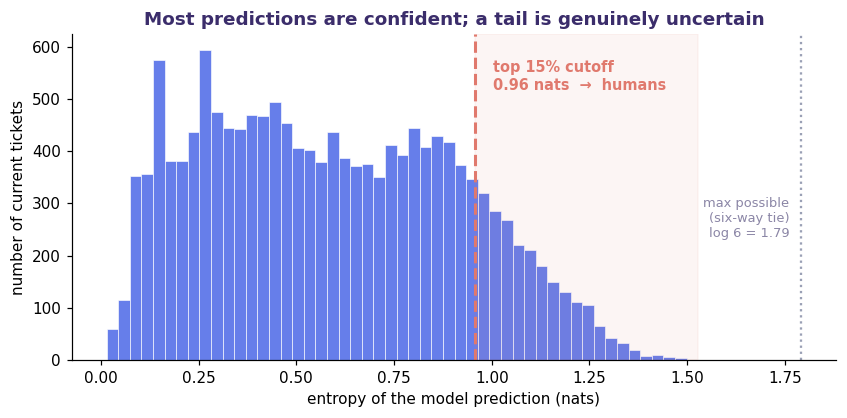

15% of current tickets sit right of the red line -> the 2250 we route to humans


In [8]:
#@title 📊 The distribution of entropy scores you just computed { display-mode: "form" }
thr = np.quantile(cur.entropy, 0.85)      # the 15%-most-uncertain cutoff
fig, ax = plt.subplots(figsize=(7.8, 3.9))
ax.hist(cur.entropy, bins=50, color=PURPLE, edgecolor='white', linewidth=0.4)
ax.axvspan(thr, cur.entropy.max() * 1.02, color=RED, alpha=0.07)
ax.axvline(thr, color=RED, ls='--', lw=2)
ax.axvline(np.log(6), color='#9aa0b5', ls=':', lw=1.5)
ymax = ax.get_ylim()[1]
ax.text(thr + 0.02, ymax * 0.92, f'  top 15% cutoff\n  {thr:.2f} nats  →  humans',
        color=RED, fontsize=9.5, fontweight='bold', va='top')
ax.text(np.log(6) - 0.03, ymax * 0.5, f'max possible\n(six-way tie)\nlog 6 = {np.log(6):.2f}',
        color='#8b86a6', fontsize=8.5, ha='right', va='top')
ax.set_xlabel('entropy of the model prediction (nats)')
ax.set_ylabel('number of current tickets')
ax.set_title('Most predictions are confident; a tail is genuinely uncertain',
             fontsize=12, fontweight='bold', color='#3b2d6b')
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()
print(f'{(cur.entropy >= thr).mean():.0%} of current tickets sit right of the red line '
      f'-> the {int((cur.entropy >= thr).sum())} we route to humans')

### The routing policy — hand the top 15% to humans

Now turn entropy into an action: flag the **15% highest-entropy** current tickets for manual
review, and let the model auto-handle the rest.

In [9]:
# 🎯 YOUR TURN — turn entropy into a routing policy.
#
# 💭 Think first: we can hand-check the 15% MOST uncertain tickets. "Most uncertain" = highest
#    entropy, so the cutoff is the 85th percentile (15% of tickets sit above it).
#
# 🎯 Implement:
#   • threshold = the 85th percentile of cur.entropy          (hint: np.quantile(values, 0.85))
#   • cur['routed_to_human'] = boolean, True where entropy >= threshold
threshold = np.quantile(cur.entropy, 0.85)
cur['routed_to_human'] = cur.entropy >= threshold

# already written for you: report the split and the payoff
n_routed = int(cur.routed_to_human.sum())
print(f'entropy threshold: {threshold:.3f} nats')
print(f'routed to humans : {n_routed:5d}  ({cur.routed_to_human.mean():.0%} of current tickets)')
print(f'auto-handled     : {len(cur)-n_routed:5d}')

correct = (cur.predicted_category == cur.true_category)
acc_routed = correct[cur.routed_to_human].mean()
acc_auto = correct[~cur.routed_to_human].mean()
print(f'\nmodel accuracy on routed (top 15% entropy): {acc_routed:.3f}')
print(f'model accuracy on auto-handled (other 85%): {acc_auto:.3f}')

entropy threshold: 0.958 nats
routed to humans :  2250  (15% of current tickets)
auto-handled     : 12750

model accuracy on routed (top 15% entropy): 0.505
model accuracy on auto-handled (other 85%): 0.739


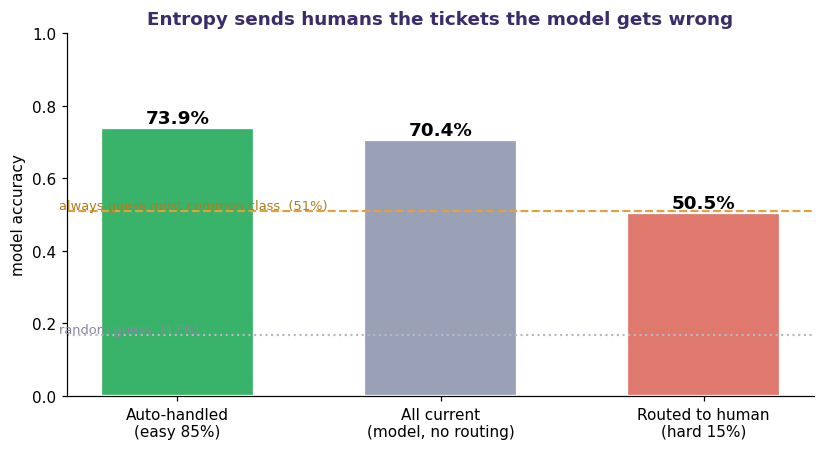

In [10]:
#@title 📊 The payoff: humans get exactly the tickets the model fails { display-mode: "form" }
overall = (cur.predicted_category == cur.true_category).mean()   # the model with NO routing
majority = cur.true_category.value_counts(normalize=True).max()  # always-guess-most-common
chance = 1 / len(CATEGORIES)                                     # random over 6 classes
vals = [acc_auto, overall, acc_routed]
labs = ['Auto-handled\n(easy 85%)', 'All current\n(model, no routing)', 'Routed to human\n(hard 15%)']
cols = [GREEN, '#9aa0b5', RED]

fig, ax = plt.subplots(figsize=(7.6, 4.2))
bars = ax.bar(labs, vals, color=cols, width=0.58, edgecolor='white', linewidth=1.5)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.014, f'{v:.1%}', ha='center', fontweight='bold', fontsize=12)
# reference baselines so the accuracies read in context
ax.axhline(majority, color=AMBER, ls='--', lw=1.4)
ax.text(-0.45, majority+0.006, f'always guess most common class  ({majority:.0%})', color='#b07d1e', fontsize=8.5)
ax.axhline(chance, color='#b7b7c6', ls=':', lw=1.4)
ax.text(-0.45, chance+0.006, f'random guess  ({chance:.0%})', color='#8b86a6', fontsize=8.5)
ax.set_ylim(0, 1.0); ax.set_ylabel('model accuracy')
ax.set_title('Entropy sends humans the tickets the model gets wrong', fontsize=12, fontweight='bold', color='#3b2d6b')
for s in ['top','right']: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

**Reading the result.** The middle bar is the model on its own, with no routing — a solid
performer, comfortably above the "always guess the most common class" and "random" baselines. The
two outer bars split that pile by entropy: the model is far more accurate on the low-entropy
tickets (left) than on the high-entropy ones (right). Entropy let us spend a *fixed* human budget
(15% of tickets) exactly where it helps most — on the ambiguous cases — without ever looking at the
true labels.

Those uncertain tickets are now handled correctly by people. But the model still auto-handles
the other 85% on its own. **How wrong is it on those?** That is a question about a *different*
quantity — not how spread out a prediction is, but how far it is from the truth. That is
cross-entropy.

# Part 2 — Cross-entropy: how wrong are the confident predictions?

Entropy only looks at the *shape* of a prediction — it never sees the correct answer. But a
ticket can be **confidently wrong**: the model puts 90% on `technical_issue`, feels sure (low
entropy, so we auto-handled it), and it was actually an `urgent_complaint`.

To measure that we need the **true label**. **Cross-entropy** is the penalty for the
probability the model assigned to the *correct* class:

$$\text{CE} = -\log p_{\text{true class}}$$

If the model gave the right class probability `0.9`, the loss is `-log 0.9 ≈ 0.1` — tiny. If it
gave the right class only `0.02`, the loss is `-log 0.02 ≈ 3.9` — huge. Cross-entropy explodes
precisely when the model put its mass on the *wrong* class and starved the right one.

We apply it to the **auto-handled** tickets (the 85% no human checked) — those are the ones
whose errors slip through.

In [11]:
#@title 🎲 Interactive: three examples, then generate your own { display-mode: "form" }
from IPython.display import HTML, display
display(HTML(r'''
<style>
.ce{font-family:system-ui,Segoe UI,Roboto,sans-serif;background:linear-gradient(135deg,#f6f8ff,#fbf5ff);
    border:1px solid #ecebff;border-radius:18px;padding:18px;max-width:740px;color:#2c2350}
.ce-h{font-size:18px;font-weight:800;color:#3b2d6b;margin:0 0 3px}
.ce-s{font-size:12px;color:#6b6685;margin:0 0 14px;line-height:1.45}
.ce-s .g{color:#2f9e5c;font-weight:700}
.ce-ex{display:flex;gap:11px;flex-wrap:wrap;margin-bottom:16px}
.ce-card{flex:1 1 200px;background:#fff;border:1px solid #eceaf6;border-radius:13px;padding:11px 12px}
.ce-tag{display:inline-block;font-size:10px;font-weight:800;border-radius:7px;padding:3px 9px;margin-bottom:10px}
.ce-mini{display:flex;align-items:flex-end;justify-content:space-between;gap:6px;height:78px;padding:0 2px}
.ce-col{flex:1;display:flex;flex-direction:column;align-items:center;justify-content:flex-end;height:100%}
.ce-bar{width:56%;max-width:15px;border-radius:5px 5px 0 0}
.ce-lab{font-size:8px;color:#a7a3bd;margin-top:5px;text-align:center;line-height:1}
.ce-eh{font-size:12px;color:#3b2d6b;margin-top:9px;font-weight:700}.ce-eh b{font-size:15px}
.ce-gen{background:#fff;border:1px solid #eceaf6;border-radius:13px;padding:14px}
.ce-btn{cursor:pointer;border:none;border-radius:11px;padding:10px 16px;font-size:13px;font-weight:800;color:#fff;
    background:linear-gradient(135deg,#667eea,#764ba2);box-shadow:0 5px 13px rgba(118,75,162,.3)}
.ce-btn:active{transform:translateY(1px)}
.ce-true{display:inline-block;margin-left:12px;font-size:12px;color:#6b6685}
.ce-true b{color:#2f9e5c}
.ce-bars{display:flex;align-items:flex-end;justify-content:space-between;gap:9px;height:120px;margin-top:14px;padding:0 2px}
.ce-read{display:flex;align-items:center;gap:16px;margin-top:12px}
.ce-num{font-size:26px;font-weight:800;color:#3b2d6b;font-variant-numeric:tabular-nums;min-width:170px}
.ce-num span{font-size:12px;color:#8b86a6;font-weight:600}
.ce-verd{flex:1;font-size:12px;font-weight:700;line-height:1.4;padding:8px 11px;border-radius:10px}
</style>
<div class="ce">
  <div class="ce-h">📉 Cross-entropy of a prediction</div>
  <div class="ce-s">Cross-entropy only cares about the probability the model gave the <span class="g">true
  class</span> (green bar): <b>CE = &minus;log(p<sub>true</sub>)</b>. Below are low, medium and high
  examples; then generate a random prediction &mdash; with a random true class &mdash; and read its loss.</div>
  <div class="ce-ex" id="ceEx"></div>
  <div class="ce-gen">
    <button class="ce-btn" id="ceBtn">🎲 Generate a random prediction</button>
    <span class="ce-true" id="ceT"></span>
    <div class="ce-bars" id="ceB"></div>
    <div class="ce-read"><div class="ce-num" id="ceN">&mdash;</div><div class="ce-verd" id="ceV"></div></div>
  </div>
</div>
<script>
(function(){
  var labs=["billing","technical","refund","sales","account","urgent"];
  var PUR="linear-gradient(180deg,#8a8ff0,#764ba2)", GRN="linear-gradient(180deg,#4fc07f,#2f9e5c)";
  function bars(container,p,h,trueIdx){container.innerHTML="";for(var i=0;i<6;i++){
    var c=document.createElement("div");c.className="ce-col";
    var b=document.createElement("div");b.className="ce-bar";b.style.height=(3+p[i]*h).toFixed(1)+"px";
    b.style.background=(i===trueIdx)?GRN:PUR;
    var l=document.createElement("div");l.className="ce-lab";l.textContent=labs[i];
    if(i===trueIdx){l.style.color="#2f9e5c";l.style.fontWeight="700";}
    c.appendChild(b);c.appendChild(l);container.appendChild(c);}}
  // --- three fixed examples (true class = urgent) ---
  var TRUE=5;
  var examples=[["✅ LOW","#eafaf0","#1f7a45",[0.05,0.06,0.04,0.03,0.02,0.80]],
                ["🤔 MEDIUM","#fdf4ea","#8a5a28",[0.14,0.26,0.11,0.08,0.06,0.35]],
                ["🚨 HIGH","#fdecea","#b3382c",[0.05,0.76,0.05,0.05,0.05,0.04]]];
  var ex=document.getElementById("ceEx");
  examples.forEach(function(e){
    var card=document.createElement("div");card.className="ce-card";
    var tag=document.createElement("div");tag.className="ce-tag";tag.textContent=e[0]+" LOSS";
    tag.style.background=e[1];tag.style.color=e[2];
    var mini=document.createElement("div");mini.className="ce-mini";
    var eh=document.createElement("div");eh.className="ce-eh";
    eh.innerHTML="CE = <b>"+(-Math.log(e[3][TRUE])).toFixed(2)+"</b> &nbsp;(p<sub>true</sub>="+e[3][TRUE].toFixed(2)+")";
    card.appendChild(tag);card.appendChild(mini);card.appendChild(eh);ex.appendChild(card);
    bars(mini,e[3],66,TRUE);
  });
  // --- random generator ---
  function gauss(){var u=1-Math.random(),v=Math.random();return Math.sqrt(-2*Math.log(u))*Math.cos(2*Math.PI*v);}
  function gen(){
    var sigma=0.4+Math.random()*2.4;
    var e=[];for(var i=0;i<6;i++)e.push(Math.exp(gauss()*sigma));
    var s=e.reduce(function(a,b){return a+b;},0);
    var p=e.map(function(v){return v/s;});
    var trueIdx=Math.floor(Math.random()*6);              // random true class
    bars(document.getElementById("ceB"),p,105,trueIdx);
    document.getElementById("ceT").innerHTML="true class: <b>"+labs[trueIdx]+"</b>";
    var pt=p[trueIdx], ce=-Math.log(pt);
    document.getElementById("ceN").innerHTML=ce.toFixed(2)+' <span>= &minus;log('+pt.toFixed(2)+')</span>';
    var v=document.getElementById("ceV");
    if(pt>0.5){v.textContent="✅ Most mass on the true class — small loss.";v.style.background="#eafaf0";v.style.color="#1f7a45";}
    else if(pt>0.15){v.textContent="🤔 The model hedged — moderate loss.";v.style.background="#fdf4ea";v.style.color="#8a5a28";}
    else{v.innerHTML="🚨 Little mass on the true class — the loss blows up.";v.style.background="#fdecea";v.style.color="#b3382c";}
  }
  document.getElementById("ceBtn").addEventListener("click",gen); gen();
})();
</script>'''))

### Exercise 2 — implement cross-entropy, then score the auto-handled tickets

Write a `cross_entropy(P, true_labels)` function — the twin of your `entropy` function, but this one
also looks at the **true** class. Then apply it to the **auto-handled** current tickets (the ones
*not* routed to a human) and see where the loss piles up.

In [12]:
# 🎯 YOUR TURN — Exercise 2: implement a cross-entropy function, then apply it.
#
# 💭 Think first: cross-entropy for one ticket is  -log(probability the model gave its TRUE class).
#    It is small when the model put mass on the right class, and explodes when it starved it.
#
# 🎯 Implement cross_entropy(P, true_labels): P is the (n, 6) probability matrix; true_labels are the
#    true category NAMES (one per row). Return one loss per row.
#    Tools (the first line is done for you — it turns names into column indices):
#      • P[np.arange(len(P)), true_idx]      -> the true-class probability for each row (fancy indexing)
#      • -np.log(np.clip(p_true, 1e-12, 1.0))
def cross_entropy(P, true_labels):
    true_idx = pd.Series(true_labels).map({c: i for i, c in enumerate(CATEGORIES)}).to_numpy()
    p_true = P[np.arange(len(P)), true_idx]
    return -np.log(np.clip(p_true, 1e-12, 1.0))
# already written for you: apply it to the auto-handled tickets and see where the loss piles up
auto = cur[~cur.routed_to_human].reset_index(drop=True)
auto['cross_entropy'] = cross_entropy(auto[PCOLS].to_numpy(), auto.true_category)

print(f'mean cross-entropy on auto-handled current tickets: {auto.cross_entropy.mean():.3f}')
print('\nmean cross-entropy by TRUE category (worst = model fails this class most):')
print(auto.groupby('true_category').cross_entropy.mean().sort_values(ascending=False).round(2))

mean cross-entropy on auto-handled current tickets: 1.060

mean cross-entropy by TRUE category (worst = model fails this class most):
true_category
urgent_complaint    6.84
refund_request      2.40
account_access      1.96
sales_question      0.91
billing             0.45
technical_issue     0.23
Name: cross_entropy, dtype: float64


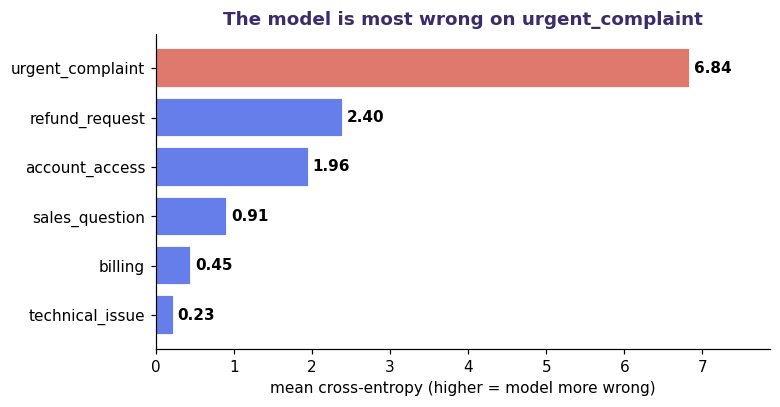

In [13]:
#@title 📊 Where the loss piles up: cross-entropy by true category { display-mode: "form" }
by_cat = auto.groupby('true_category').cross_entropy.mean().sort_values()
cols = [RED if c == 'urgent_complaint' else PURPLE for c in by_cat.index]

fig, ax = plt.subplots(figsize=(7.2, 3.8))
bars = ax.barh(range(len(by_cat)), by_cat.values, color=cols, edgecolor='white', linewidth=1.2)
ax.set_yticks(range(len(by_cat))); ax.set_yticklabels(by_cat.index)
for i, v in enumerate(by_cat.values):
    ax.text(v+0.05, i, f'{v:.2f}', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('mean cross-entropy (higher = model more wrong)')
ax.set_title('The model is most wrong on urgent_complaint', fontsize=12, fontweight='bold', color='#3b2d6b')
ax.set_xlim(0, by_cat.max()*1.15)
for s in ['top','right']: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

In [14]:
#@title 📊 A worst offender: mass on the wrong class, true class starved { display-mode: "form" }
worst = auto.nlargest(1, 'cross_entropy').iloc[0]
p = worst[PCOLS].to_numpy(dtype=float)
true_c = worst['true_category']

rows = ''
for c, v in zip(CATEGORIES, p):
    is_true = (c == true_c)
    col = '#39b36a' if is_true else '#764ba2'
    tag = '  ← TRUE class' if is_true else ''
    rows += (f'<div class="wo-row"><div class="wo-lab">{c}{tag}</div>'
             f'<div class="wo-track"><div class="wo-fill" style="width:{v*100:.1f}%;background:{col}"></div></div>'
             f'<div class="wo-val">{v:.3f}</div></div>')

css = r'''<style>
.wo{font-family:system-ui,Segoe UI,Roboto,sans-serif;background:#fff;border:1px solid #e6e8ee;border-radius:14px;
    padding:16px 18px;max-width:640px;color:#2c2350}
.wo-h{font-size:15px;font-weight:800;color:#3b2d6b;margin:0 0 10px}
.wo-row{display:flex;align-items:center;gap:9px;margin:5px 0}
.wo-lab{font-size:11px;color:#6b6685;width:170px;text-align:right}
.wo-track{flex:1;height:9px;background:#f1f0f8;border-radius:999px;overflow:hidden}
.wo-fill{height:100%;border-radius:999px}
.wo-val{font-size:11px;color:#3b2d6b;width:44px;font-variant-numeric:tabular-nums}
.wo-cap{font-size:11.5px;color:#6b6685;margin-top:11px;line-height:1.45;background:#fdecea;border-radius:10px;
    padding:9px 11px}.wo-cap b{color:#b3382c}
</style>'''
body = f'''<div class="wo"><div class="wo-h">🚨 Highest-loss auto-handled ticket &nbsp;·&nbsp; cross-entropy = {worst.cross_entropy:.2f}</div>
{rows}
<div class="wo-cap">The model predicted <b>{worst.predicted_category}</b> with high confidence and gave the true class
<b>{true_c}</b> almost no probability ({p[CATEGORIES.index(true_c)]:.3f}). No human saw it — it slipped straight through.</div></div>'''
display(HTML(css + body))

**Reading the result.** The costly, confident mistakes are overwhelmingly on one class:
**`urgent_complaint`**. And here is the twist — `urgent_complaint` used to be one of the *rarest*
categories. The model was calibrated on a world where urgent complaints almost never happened,
so it learned to almost never predict them. Now they are slipping through, confidently
mislabelled as something calmer.

That smells like the **mix of tickets has changed** since the model was trained. To check that
suspicion we need to compare two whole distributions — historical versus current — with a single
number. That is KL divergence.

# Part 3 — KL divergence: did the ticket mix shift?

We suspect the **distribution of ticket categories** drifted between the `historical` period the
model was trained on and the `current` three months. **KL divergence** measures exactly how far
the current distribution $Q$ has moved from the historical one $P$:

$$D_{\text{KL}}(Q \,\|\, P) = \sum_{c} Q_c \, \log \frac{Q_c}{P_c}$$

It is `0` when the two distributions are identical and grows as they diverge. Beautifully, it is
a **sum over categories** — so each category contributes its own term $Q_c \log (Q_c / P_c)$, and
we can read off *which* categories drove the shift.

We will compute it three ways, zooming in each time:

1. **Global** — did the overall category mix shift?
2. **By category** — which categories contributed most?
3. **By product** — a large product update shipped three months ago; which product caused it?

In [ ]:
#@title 🌊 Intuition: how to read a KL divergence { display-mode: "form" }
from IPython.display import HTML, display
display(HTML(r'''
<style>
.kl{font-family:system-ui,Segoe UI,Roboto,sans-serif;background:linear-gradient(135deg,#f6f8ff,#fbf5ff);
    border:1px solid #ecebff;border-radius:18px;padding:18px;max-width:760px;color:#2c2350}
.kl-h{font-size:18px;font-weight:800;color:#3b2d6b;margin:0 0 3px}
.kl-s{font-size:12px;color:#6b6685;margin:0 0 14px;line-height:1.45}
.kl-s b{color:#3b2d6b}
.kl-scale{display:flex;gap:8px;margin:0 0 16px}
.kl-chip{flex:1;background:#fff;border:1px solid #eceaf6;border-radius:10px;padding:8px 9px;text-align:center;
    font-size:11px;font-weight:800;color:#3b2d6b;border-top:3px solid #c9c6de}
.kl-chip span{display:block;font-size:9.5px;color:#8b86a6;font-weight:600;margin-top:2px}
.kl-ex{display:flex;gap:11px;flex-wrap:wrap;margin-bottom:15px}
.kl-card{flex:1 1 200px;background:#fff;border:1px solid #eceaf6;border-radius:13px;padding:11px 12px}
.kl-tag{display:inline-block;font-size:10px;font-weight:800;border-radius:7px;padding:3px 9px;margin-bottom:10px}
.kl-mini{display:flex;align-items:flex-end;justify-content:space-around;gap:8px;height:66px}
.kl-grp{display:flex;align-items:flex-end;gap:3px;height:100%}
.kl-b{width:9px;border-radius:4px 4px 0 0}
.kl-bp{background:#c3c7db}.kl-bq{background:linear-gradient(180deg,#8a8ff0,#764ba2)}
.kl-glab{font-size:8px;color:#a7a3bd;text-align:center;margin-top:4px}
.kl-eh{font-size:12px;color:#3b2d6b;margin-top:9px;font-weight:700}.kl-eh b{font-size:15px}
.kl-leg{font-size:10px;color:#8b86a6;margin:-6px 0 12px}
.kl-leg i{font-style:normal;padding:1px 6px;border-radius:4px;color:#fff}
.kl-key{background:#fff;border:1px solid #e6d9f3;border-radius:13px;padding:13px 15px}
.kl-kh{font-size:13px;font-weight:800;color:#5a3d9b;margin-bottom:8px}
.kl-krow{display:flex;align-items:center;gap:10px;font-size:12px;margin:6px 0;padding:7px 10px;border-radius:9px}
.kl-krow.common{background:#f5f5fb}.kl-krow.rare{background:#f3ecfb}
.kl-krow .desc{flex:1;color:#6b6685}.kl-krow .desc b{color:#3b2d6b}
.kl-krow .term{font-weight:800;font-variant-numeric:tabular-nums;font-size:14px}
.kl-note{font-size:11.5px;color:#6b6685;margin-top:9px;line-height:1.45}.kl-note b{color:#5a3d9b}
</style>
<div class="kl">
  <div class="kl-h">🌊 How to read a KL divergence</div>
  <div class="kl-s">KL(Q&thinsp;&#8214;&thinsp;P) measures how <b>surprised</b> you would be to see the current mix
  <b>Q</b> when you expected the historical mix <b>P</b>. It is <b>0</b> when they are identical and has
  <b>no upper limit</b> &mdash; the further Q drifts from P, the bigger it grows (measured in nats).</div>
  <div class="kl-scale">
    <div class="kl-chip" style="border-top-color:#39b36a">0<span>identical — no shift</span></div>
    <div class="kl-chip" style="border-top-color:#8bc34a">~0.05<span>slight drift</span></div>
    <div class="kl-chip" style="border-top-color:#e0a23c">~0.3<span>clearly shifted</span></div>
    <div class="kl-chip" style="border-top-color:#e0796d">&gt;1<span>dramatic</span></div>
  </div>
  <div class="kl-leg">each category shows two bars: <i style="background:#c3c7db">P historical</i>
    &nbsp;vs&nbsp; <i style="background:#764ba2">Q current</i></div>
  <div class="kl-ex" id="klEx"></div>
  <div class="kl-key">
    <div class="kl-kh">🔑 The trick to reading the numbers: a <u>rare</u> category that grows hurts most</div>
    <div class="kl-krow common"><div class="desc">a <b>common</b> category: P=0.40 &rarr; Q=0.46
      &nbsp;(<b>+0.06</b>)</div><div class="term" id="klC"></div></div>
    <div class="kl-krow rare"><div class="desc">a <b>rare</b> category: P=0.01 &rarr; Q=0.07
      &nbsp;(<b>+0.06</b>)</div><div class="term" id="klR"></div></div>
    <div class="kl-note">Same <b>+0.06</b> change &mdash; but the rare category adds far more to KL, because its
    term <span style="font-family:monospace">Q&middot;log(Q/P)</span> blows up when P was tiny (here the ratio
    Q/P is 7&times;). <b>That is exactly why a once-rare class like <span style="color:#b3382c">urgent_complaint</span>
    can dominate the whole shift.</b></div>
  </div>
</div>
<script>
(function(){
  function kl(Q,P){var s=0;for(var i=0;i<Q.length;i++){if(Q[i]>1e-12)s+=Q[i]*Math.log(Q[i]/P[i]);}return s;}
  var labs=["A","B","C","D"];
  var examples=[["✅ LOW","#eafaf0","#1f7a45",[0.40,0.30,0.20,0.10],[0.42,0.30,0.18,0.10]],
                ["🤔 MEDIUM","#fdf4ea","#8a5a28",[0.40,0.30,0.20,0.10],[0.28,0.27,0.25,0.20]],
                ["🚨 HIGH","#fdecea","#b3382c",[0.55,0.30,0.10,0.05],[0.22,0.24,0.24,0.30]]];
  var ex=document.getElementById("klEx");
  examples.forEach(function(e){
    var P=e[3],Q=e[4];
    var card=document.createElement("div");card.className="kl-card";
    var tag=document.createElement("div");tag.className="kl-tag";tag.textContent=e[0]+" KL";
    tag.style.background=e[1];tag.style.color=e[2];
    var mini=document.createElement("div");mini.className="kl-mini";
    for(var i=0;i<4;i++){
      var col=document.createElement("div");col.style.display="flex";col.style.flexDirection="column";col.style.alignItems="center";
      var grp=document.createElement("div");grp.className="kl-grp";
      var bp=document.createElement("div");bp.className="kl-b kl-bp";bp.style.height=(2+P[i]*80).toFixed(1)+"px";
      var bq=document.createElement("div");bq.className="kl-b kl-bq";bq.style.height=(2+Q[i]*80).toFixed(1)+"px";
      grp.appendChild(bp);grp.appendChild(bq);
      var gl=document.createElement("div");gl.className="kl-glab";gl.textContent=labs[i];
      col.appendChild(grp);col.appendChild(gl);mini.appendChild(col);
    }
    var eh=document.createElement("div");eh.className="kl-eh";eh.innerHTML="KL = <b>"+kl(Q,P).toFixed(3)+"</b> nats";
    card.appendChild(tag);card.appendChild(mini);card.appendChild(eh);ex.appendChild(card);
  });
  var tc=0.46*Math.log(0.46/0.40), tr=0.07*Math.log(0.07/0.01);
  document.getElementById("klC").innerHTML="term = "+tc.toFixed(3);
  document.getElementById("klC").style.color="#8b86a6";
  document.getElementById("klR").innerHTML="term = "+tr.toFixed(3);
  document.getElementById("klR").style.color="#b3382c";
})();
</script>'''))

### Exercise 3a — the global KL divergence

Build the historical and current category distributions and compute a single $D_{\text{KL}}(Q\|P)$.

In [15]:
# 🎯 YOUR TURN — Exercise 3a: the global KL divergence.
#
# 💭 Think first: KL(Q || P) = sum_c  Q_c * log(Q_c / P_c). It is 0 when the two distributions
#    match and grows as they separate. Here P = historical mix, Q = current mix.
#
# already written for you: turn a column of labels into a probability vector over CATEGORIES
def category_distribution(labels):
    counts = pd.Series(labels).value_counts(normalize=True)
    return np.array([counts.get(c, 0.0) for c in CATEGORIES])

# 🎯 Implement kl_divergence(q, p): after the clips, sum q*log(q/p) and return a float.
def kl_divergence(q, p):
    q = np.clip(q, 1e-12, 1.0); p = np.clip(p, 1e-12, 1.0)
    return (q * np.log(q / p)).sum()

P = category_distribution(hist.true_category)   # historical reference
Q = category_distribution(cur.true_category)    # current
global_kl = kl_divergence(Q, P)
print(f'global KL(current || historical) = {global_kl:.4f}')
print('\n         category   historical   current')
for c, ph, qc in zip(CATEGORIES, P, Q):
    print(f'{c:>18s}      {ph:6.3f}    {qc:6.3f}   {"  <-- grew" if qc>ph+0.01 else ""}')

global KL(current || historical) = 0.2558

         category   historical   current
           billing       0.203     0.166   
   technical_issue       0.571     0.510   
    refund_request       0.030     0.062     <-- grew
    sales_question       0.114     0.117   
    account_access       0.082     0.074   
  urgent_complaint       0.001     0.072     <-- grew


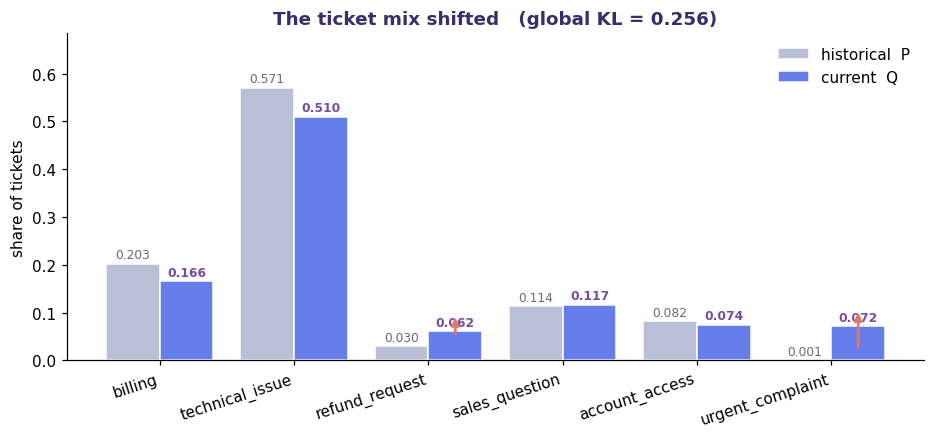

In [16]:
#@title 📊 Historical vs current category mix (your P and Q) { display-mode: "form" }
x = np.arange(len(CATEGORIES)); w = 0.4
fig, ax = plt.subplots(figsize=(8.6, 4.1))
ax.bar(x - w/2, P, w, color='#b9bfd6', edgecolor='white', label='historical  P')
ax.bar(x + w/2, Q, w, color=PURPLE, edgecolor='white', label='current  Q')
for xi, ph, qc in zip(x, P, Q):
    ax.text(xi - w/2, ph + 0.005, f'{ph:.3f}', ha='center', va='bottom', fontsize=8, color='#6b6685')
    ax.text(xi + w/2, qc + 0.005, f'{qc:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold', color=PURPLE2)
    if qc > ph + 0.005:      # flag the categories that grew
        ax.annotate('', xy=(xi + w/2, qc + 0.035), xytext=(xi + w/2, ph + 0.02),
                    arrowprops=dict(arrowstyle='-|>', color=RED, lw=1.8))
ax.set_xticks(x); ax.set_xticklabels(CATEGORIES, rotation=18, ha='right')
ax.set_ylabel('share of tickets'); ax.set_ylim(0, max(P.max(), Q.max()) * 1.2)
ax.set_title(f'The ticket mix shifted   (global KL = {global_kl:.3f})',
             fontsize=12, fontweight='bold', color='#3b2d6b')
ax.legend(frameon=False, loc='upper right')
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

### Exercise 3b — which categories contributed the shift?

Because KL is a sum over categories, split it into its per-category terms
$Q_c \log(Q_c/P_c)$ and see which dominate.

In [17]:
# 🎯 YOUR TURN — Exercise 3b: split the KL into per-category contributions.
#
# 💭 Think first: KL is a SUM over categories, so each category c owns one term
#    Q_c * log(Q_c / P_c). Those terms add up to the global KL. Which are biggest?
#
# 🎯 Implement kl_terms: the per-category ARRAY Q_c * log(Q_c / P_c) (elementwise, not summed).
Qc, Pc = np.clip(Q, 1e-12, 1), np.clip(P, 1e-12, 1)
kl_terms = np.array(Qc * np.log(Qc / Pc))

# already written for you: sort and report
contrib = pd.Series(kl_terms, index=CATEGORIES).sort_values(ascending=False)
print('KL contribution by category (sums to the global KL):')
print(contrib.round(4))
print(f'\nsum = {contrib.sum():.4f}   (matches global KL = {global_kl:.4f})')
growth = contrib[contrib > 0].sum()
print(f'urgent_complaint is {contrib["urgent_complaint"]/growth:.0%} of all the upward pressure on the mix')

KL contribution by category (sums to the global KL):
urgent_complaint    0.3062
refund_request      0.0449
sales_question      0.0027
account_access     -0.0074
billing            -0.0332
technical_issue    -0.0573
dtype: float64

sum = 0.2558   (matches global KL = 0.2558)
urgent_complaint is 87% of all the upward pressure on the mix


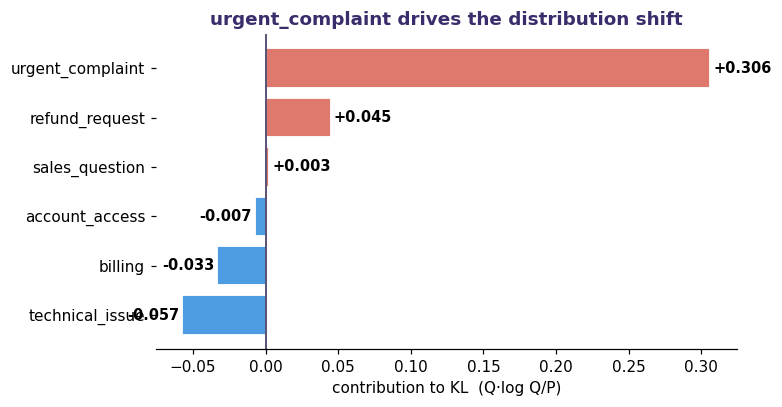

In [18]:
#@title 📊 KL contribution by category { display-mode: "form" }
cols = [RED if v > 0 else '#4d9be0' for v in contrib.values]
fig, ax = plt.subplots(figsize=(7.2, 3.8))
bars = ax.barh(range(len(contrib)), contrib.values[::-1], color=cols[::-1], edgecolor='white', linewidth=1.2)
ax.set_yticks(range(len(contrib))); ax.set_yticklabels(contrib.index[::-1])
for i, v in enumerate(contrib.values[::-1]):
    ax.text(v + (0.002 if v >= 0 else -0.002), i, f'{v:+.3f}', va='center',
            ha='left' if v >= 0 else 'right', fontsize=9.5, fontweight='bold')
ax.axvline(0, color='#2c2350', lw=1)
ax.set_xlabel('contribution to KL  (Q·log Q/P)')
ax.set_title('urgent_complaint drives the distribution shift', fontsize=12, fontweight='bold', color='#3b2d6b')
for s in ['top','right','left']: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

**Notice what just happened.** `urgent_complaint` is still only about **7%** of current tickets — a
small slice — yet it accounts for the large majority of the KL. KL doesn't care about a category's
*absolute size*; it reacts to how much its share **multiplied**. A class that went from roughly
**0.1% to ~7%** is a ~70× jump, and that is what the divergence lights up. This is exactly why the
metric is useful: it surfaces a real shift in a rare-but-important class that a glance at the biggest
categories would completely miss.

### Exercise 3c — which product caused it?

The global KL told us the mix moved; the per-category split told us *which category* grew. But we
still don't know **why**. Here's the lead: three months ago the company shipped a big update across
**all** its products. If the update to *one* product changed the kind of tickets it produces, the
shift should be concentrated **inside that product** — every other product's mix would look unchanged.

So compute **KL(current ‖ historical) separately within each product area**. A product whose update
was harmless scores ≈ 0; the culprit stands out with a much larger KL. **For you as the analyst that
is the payoff: it turns a vague "the model got worse" into one concrete, actionable target — the
single product to roll back, retrain on, or add a rule for.**

**What to use:** reuse the `category_distribution()` and `kl_divergence()` helpers you just wrote.
Loop over `PRODUCTS`; for each `prod`, filter both periods to that product
(`hist[hist.product_area == prod]` and `cur[cur.product_area == prod]`), build its historical `P` and
current `Q` category distributions, and take their KL. Collect the `(product, kl)` pairs and drop them
into a `pd.Series` so you can sort the products from most- to least-shifted.

In [19]:
# 🎯 YOUR TURN — Exercise 3c: KL divergence within each product.
#
# 💭 Think first: a big update shipped across ALL products. If one product's update changed the
#    tickets it creates, its within-product KL will dominate. Reuse category_distribution() and
#    kl_divergence() from before.
#
# 🎯 Implement the loop body for each prod in PRODUCTS:
#    1. Filter historical rows for this product, then build P:
#         hist[hist.product_area == prod].true_category
#         → pass that Series into category_distribution(...)
#    2. Same for current rows → Q via category_distribution(cur[...].true_category)
#    3. Score the shift with kl_divergence(q_prod, p_prod)
#       (order matters: KL(Q || P) = current vs historical reference)
rows = []
for prod in PRODUCTS:
    p_prod = category_distribution(hist[hist.product_area == prod].true_category)
    q_prod = category_distribution(cur[cur.product_area == prod].true_category)

    rows.append((prod, kl_divergence(q_prod, p_prod)))

# already written for you: sort and report
per_product = pd.Series(dict(rows)).sort_values(ascending=False)
print('KL(current || historical) within each product:')
print(per_product.round(4))
print(f'\n--> {per_product.index[0]} shifted {per_product.iloc[0]/per_product.iloc[1]:.0f}x '
      f'more than the next product. That update is the culprit.')


KL(current || historical) within each product:
mobile_app       1.7020
payments         0.1087
search           0.0031
api              0.0026
notifications    0.0018
analytics        0.0017
dtype: float64

--> mobile_app shifted 16x more than the next product. That update is the culprit.


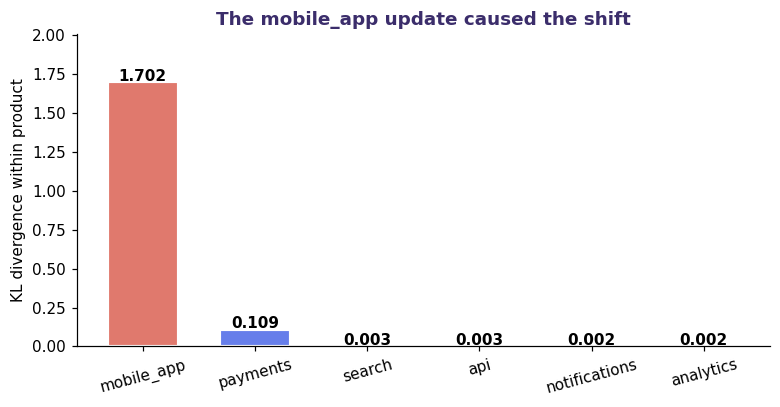

In [20]:
#@title 📊 KL per product: the culprit stands out { display-mode: "form" }
cols = [RED if p == per_product.index[0] else PURPLE for p in per_product.index]
fig, ax = plt.subplots(figsize=(7.2, 3.8))
bars = ax.bar(range(len(per_product)), per_product.values, color=cols, edgecolor='white', linewidth=1.4, width=0.62)
ax.set_xticks(range(len(per_product))); ax.set_xticklabels(per_product.index, rotation=15)
for b, v in zip(bars, per_product.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.008, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('KL divergence within product')
ax.set_title('The mobile_app update caused the shift', fontsize=12, fontweight='bold', color='#3b2d6b')
ax.set_ylim(0, per_product.max()*1.18)
for s in ['top','right']: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

**Reading the result.** The shift is overwhelmingly inside **`mobile_app`**. Its update changed
the tickets it produces: many more of them are now `urgent_complaint`, a class the frozen model
barely predicts. That single product explains most of the global KL — and most of the
cross-entropy pain from Part 2.

But *why* did mobile_app tickets turn urgent? *Which feature* now signals an urgent complaint that
did not before? For that we need to ask how much a feature tells us about the category — mutual
information.

# Part 4 — Mutual information: which feature now carries the signal?

We have found *where* (mobile_app) and *what* (a surge of urgent complaints). The last question is
*why*: which **feature** became predictive of the category after the update?

**Mutual information** measures how much knowing a feature $X$ reduces our uncertainty about the
category $Y$:

$$I(X;Y) = H(Y) - H(Y \mid X)$$

If a feature tells you nothing about the category, $I = 0$. If it pins the category down, $I$ is
large. By computing MI **before** and **after** the update — inside mobile_app — we can see which
signal the model is now blind to.

In [21]:
#@title 📊 The idea: a feature that splits the categories carries information { display-mode: "form" }
css = r'''<style>
.mi{font-family:system-ui,Segoe UI,Roboto,sans-serif;background:linear-gradient(135deg,#f6f8ff,#fbf5ff);
    border:1px solid #ecebff;border-radius:18px;padding:18px;max-width:780px;color:#2c2350}
.mi-h{font-size:17px;font-weight:800;color:#3b2d6b;margin:0 0 3px}
.mi-s{font-size:12px;color:#6b6685;margin:0 0 14px;line-height:1.45}
.mi-row{display:flex;gap:14px;flex-wrap:wrap}
.mi-card{flex:1 1 320px;background:#fff;border:1px solid #e6e8ee;border-radius:13px;padding:13px 15px}
.mi-tag{display:inline-block;font-size:10.5px;font-weight:800;border-radius:7px;padding:3px 9px;margin-bottom:9px}
.mi-split{display:flex;gap:8px;margin:8px 0}
.mi-bucket{flex:1;border:1px dashed #d9d3f3;border-radius:9px;padding:7px 8px;text-align:center}
.mi-bk{font-size:10px;color:#8b86a6;margin-bottom:5px;font-weight:700}
.mi-chips{display:flex;flex-wrap:wrap;gap:3px;justify-content:center}
.mi-chip{font-size:9px;padding:2px 5px;border-radius:5px;color:#fff}
.mi-cap{font-size:11px;color:#6b6685;margin-top:8px;line-height:1.4}.mi-cap b{color:#3b2d6b}
</style>'''
body = r'''<div class="mi">
  <div class="mi-h">🔗 Does splitting on a feature make the category predictable?</div>
  <div class="mi-s">Take mobile_app tickets and split them by <b>waiting time</b>. If each side becomes
  dominated by one category, waiting time carries a lot of information about the category (high MI).</div>
  <div class="mi-row">
    <div class="mi-card"><div class="mi-tag" style="background:#eef3ff;color:#4d6fd6">BEFORE the update</div>
      <div class="mi-split">
        <div class="mi-bucket"><div class="mi-bk">short wait</div><div class="mi-chips">
          <span class="mi-chip" style="background:#667eea">technical</span><span class="mi-chip" style="background:#764ba2">account</span>
          <span class="mi-chip" style="background:#9aa0b5">billing</span></div></div>
        <div class="mi-bucket"><div class="mi-bk">long wait</div><div class="mi-chips">
          <span class="mi-chip" style="background:#667eea">technical</span><span class="mi-chip" style="background:#764ba2">account</span>
          <span class="mi-chip" style="background:#9aa0b5">billing</span></div></div>
      </div>
      <div class="mi-cap">Both sides look the same &rarr; waiting time says <b>little</b> about the category. <b>Low MI.</b></div></div>
    <div class="mi-card"><div class="mi-tag" style="background:#fdecea;color:#b3382c">AFTER the update</div>
      <div class="mi-split">
        <div class="mi-bucket"><div class="mi-bk">short wait</div><div class="mi-chips">
          <span class="mi-chip" style="background:#667eea">technical</span><span class="mi-chip" style="background:#764ba2">account</span></div></div>
        <div class="mi-bucket"><div class="mi-bk">long wait</div><div class="mi-chips">
          <span class="mi-chip" style="background:#e0796d">urgent</span><span class="mi-chip" style="background:#e0796d">urgent</span>
          <span class="mi-chip" style="background:#e0796d">urgent</span></div></div>
      </div>
      <div class="mi-cap">Long waits now turn into <b>urgent</b> complaints &rarr; waiting time predicts the category. <b>High MI.</b></div></div>
  </div>
</div>'''
display(HTML(css + body))

### Exercise 4 — MI of each feature with the category, before vs after

Inside `mobile_app`, compute the mutual information between each feature and the true category —
once on `historical` tickets, once on `current` — and compare.

In [22]:
# 🎯 YOUR TURN — Exercise 4: mutual information per feature, before vs after.
#
# 💭 Think first: mutual information I(X;Y) says how much knowing a feature X reduces uncertainty
#    about the category Y. We compute it inside mobile_app, once on historical and once on current,
#    and compare — the feature whose MI JUMPS is the new signal the model is blind to.
#
# already written for you: the feature list and which of them are discrete-valued
features = ['message_length', 'waiting_time_hours', 'previous_tickets_30d',
            'customer_value_score', 'submitted_weekend']
discrete = [False, False, True, False, True]

# 🎯 Implement mi_within(sub):
#    • sub / y are already filtered for you below
#    • Build `scores` as a list of one MI value per feature
#    • Loop over features and discrete together with zip(features, discrete)
#    • For each (f, d), call sklearn's mutual_info_classif:
#        mutual_info_classif(
#            sub[[f]].to_numpy(),   # X: one feature column as a 2-D array
#            y,                    # labels: true_category
#            discrete_features=[d],
#            random_state=RANDOM_STATE,
#        )[0]                      # [0] because it returns an array of length 1
#    Hint shape: scores = [mutual_info_classif(...)[0] for f, d in zip(features, discrete)]
def mi_within(sub):
    sub = sub[sub.product_area == 'mobile_app']
    y = sub.true_category.to_numpy()
    scores = [mutual_info_classif(sub[[f]].to_numpy(),y,discrete_features=[d],random_state=RANDOM_STATE,)[0]for f, d in zip(features, discrete)]
    return pd.Series(scores, index=features)

# already written for you: run it before/after and compare
mi_hist = mi_within(hist)
mi_cur = mi_within(cur)
mi_table = pd.DataFrame({'historical': mi_hist, 'current': mi_cur})
mi_table['change'] = mi_table.current - mi_table.historical
print('Mutual information with true_category, inside mobile_app:')
print(mi_table.sort_values('change', ascending=False).round(3))


Mutual information with true_category, inside mobile_app:
                      historical  current  change
waiting_time_hours         0.002    0.379   0.376
previous_tickets_30d       0.014    0.057   0.043
submitted_weekend          0.000    0.001   0.001
customer_value_score       0.006    0.004  -0.002
message_length             0.071    0.033  -0.038


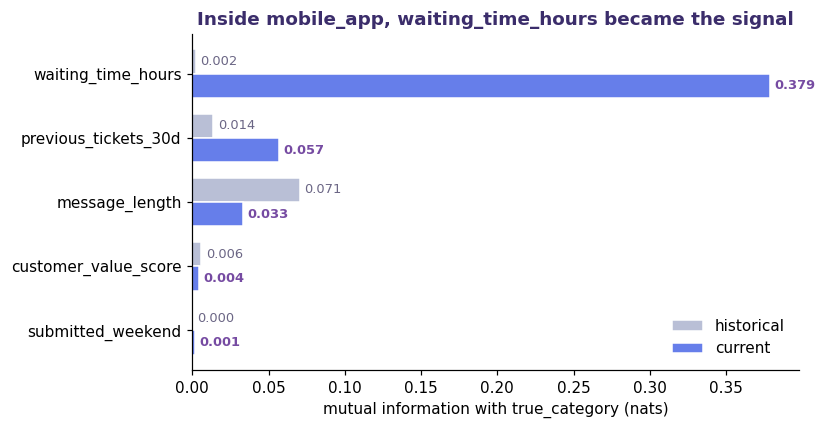

In [23]:
#@title 📊 Which feature lit up after the update { display-mode: "form" }
order = mi_table.sort_values('current', ascending=True)
y = np.arange(len(order)); h = 0.38
fig, ax = plt.subplots(figsize=(7.6, 4))
ax.barh(y+h/2, order.historical, height=h, color='#b9bfd6', label='historical', edgecolor='white')
ax.barh(y-h/2, order.current, height=h, color=PURPLE, label='current', edgecolor='white')
for i, (hv, cv) in enumerate(zip(order.historical, order.current)):
    ax.text(hv+0.003, i+h/2, f'{hv:.3f}', va='center', fontsize=8.5, color='#6b6685')
    ax.text(cv+0.003, i-h/2, f'{cv:.3f}', va='center', fontsize=8.5, fontweight='bold', color=PURPLE2)
ax.set_yticks(y); ax.set_yticklabels(order.index)
ax.set_xlabel('mutual information with true_category (nats)')
ax.set_title('Inside mobile_app, waiting_time_hours became the signal', fontsize=12, fontweight='bold', color='#3b2d6b')
ax.legend(loc='lower right', frameon=False)
for s in ['top','right']: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

**Reading the result.** Before the update, no feature said much about a mobile_app ticket's
category. After it, **`waiting_time_hours`** carries far more information than anything else: long
waits now turn into `urgent_complaint`s. The update evidently made slow responses escalate into
urgent complaints — a relationship the frozen model never learned, which is why it keeps filing
them under `technical_issue`.

That is the full chain, closed by evidence: *what* to fix (retrain on the new mix / add a
waiting-time escalation rule for mobile_app), *why* (waiting time now drives urgency there), and
*where* it hurts (the urgent complaints slipping through auto-handling).

# Summary — one investigation, four metrics

In [24]:
#@title 🔬 The four metrics at a glance { display-mode: "form" }
from IPython.display import HTML, display
display(HTML(r'''
<style>
.sm{font-family:system-ui,Segoe UI,Roboto,sans-serif;background:linear-gradient(135deg,#f6f8ff,#fbf5ff);
    border:1px solid #ecebff;border-radius:18px;padding:20px;max-width:820px;color:#2c2350}
.sm-h{font-size:19px;font-weight:800;color:#3b2d6b;margin:0 0 3px}
.sm-sub{font-size:12px;color:#6b6685;margin:0 0 16px;line-height:1.45}
.sm-row{display:flex;align-items:center;gap:14px;background:#fff;border:1px solid #eceaf6;border-radius:14px;
    padding:12px 14px;margin-bottom:10px;border-left:5px solid #ccc}
.sm-badge{flex:0 0 46px;width:46px;height:46px;border-radius:50%;display:flex;align-items:center;justify-content:center;
    font-size:22px;color:#fff;position:relative;box-shadow:0 5px 12px rgba(102,126,234,.28)}
.sm-badge span{position:absolute;bottom:-4px;right:-4px;width:19px;height:19px;border-radius:50%;background:#fff;
    color:#3b2d6b;font-size:11px;font-weight:800;display:flex;align-items:center;justify-content:center;border:1px solid #eceaf6}
.sm-mid{flex:0 0 220px}
.sm-name{font-size:14.5px;font-weight:800;color:#2c2350}
.sm-f{display:inline-block;margin-top:5px;font-family:ui-monospace,Menlo,Consolas,monospace;font-size:11.5px;
    color:#5a3d9b;background:#f3eefb;border-radius:7px;padding:4px 9px}
.sm-find{flex:1;font-size:12.5px;color:#6b6685;line-height:1.45}.sm-find b{color:#3b2d6b}
.sm-through{margin-top:6px;background:linear-gradient(135deg,#eef1ff,#f6eefb);border:1px solid #e2dcf3;
    border-radius:14px;padding:14px 16px;font-size:12.5px;color:#4a4568;line-height:1.55}
.sm-through b{color:#3b2d6b}
.sm-rows{margin-bottom:6px}
</style>
<div class="sm">
  <div class="sm-h">🔬 Four metrics, one investigation</div>
  <div class="sm-sub">Each information-theoretic quantity answered one question and handed the case to the next.</div>
  <div class="sm-rows" id="smRows"></div>
  <div class="sm-through">
    <b>The throughline.</b> Every question about a model&rsquo;s behaviour turned out to be a question about
    <b>probability distributions</b> &mdash; how peaked (entropy), how far from the truth (cross-entropy),
    how far two have drifted (KL divergence), and how much one variable tells you about another (mutual
    information). <b>Four numbers, one coherent story.</b>
  </div>
</div>
<script>
(function(){
  var rows=[
    ["🎯","1","Entropy","H = −Σ p·log p","#667eea",
     "The model is <b>unsure on ~15%</b> of tickets — route those to humans."],
    ["📉","2","Cross-entropy","CE = −log p(true)","#8a6fe0",
     "The confident mistakes <b>cluster on urgent_complaint</b>."],
    ["🌊","3","KL divergence","D(Q‖P) = Σ Q·log(Q/P)","#b06fd0",
     "The ticket mix <b>shifted</b> — and the <b>mobile_app</b> update caused it."],
    ["🔗","4","Mutual information","I(X;Y) = H(Y) − H(Y|X)","#db6fa9",
     "<b>waiting_time_hours</b> is the new signal driving urgency."]
  ];
  var box=document.getElementById("smRows");
  rows.forEach(function(r){
    var row=document.createElement("div");row.className="sm-row";row.style.borderLeftColor=r[4];
    var b=document.createElement("div");b.className="sm-badge";
    b.style.background="linear-gradient(135deg,"+r[4]+","+r[4]+"cc)";
    b.innerHTML=r[0]+'<span>'+r[1]+'</span>';
    var mid=document.createElement("div");mid.className="sm-mid";
    mid.innerHTML='<div class="sm-name">'+r[2]+'</div><div class="sm-f">'+r[3]+'</div>';
    var f=document.createElement("div");f.className="sm-find";f.innerHTML=r[5];
    row.appendChild(b);row.appendChild(mid);row.appendChild(f);box.appendChild(row);
  });
})();
</script>'''))

In [25]:
#@title 🗺️ The investigation, end to end { display-mode: "form" }
from IPython.display import HTML, display
display(HTML(r'''
<style>
.jn{font-family:system-ui,Segoe UI,Roboto,sans-serif;background:linear-gradient(135deg,#f6f8ff,#fbf5ff);
    border:1px solid #ecebff;border-radius:18px;padding:20px;max-width:820px;color:#2c2350}
.jn-h{font-size:19px;font-weight:800;color:#3b2d6b;margin:0 0 14px;text-align:center}
.jn-step{display:flex;align-items:flex-start;gap:14px;margin:0}
.jn-ic{width:44px;height:44px;border-radius:50%;flex:0 0 44px;display:flex;align-items:center;justify-content:center;
    font-size:20px;color:#fff;box-shadow:0 5px 12px rgba(102,126,234,.3)}
.jn-body{flex:1;padding-bottom:14px}
.jn-t{font-weight:800;font-size:14px;color:#2c2350}
.jn-d{font-size:12px;color:#6b6685;margin-top:2px;line-height:1.4}
.jn-conn{width:2px;height:20px;background:#d9d3f3;margin-left:21px}
.jn-find{font-size:11.5px;color:#1f7a45;font-weight:700;margin-top:3px}
</style>
<div class="jn">
  <div class="jn-h">🔎 From &ldquo;the model got worse&rdquo; to a root cause</div>
  <div class="jn-step"><div class="jn-ic" style="background:linear-gradient(135deg,#667eea,#7b71ee)">🎯</div>
    <div class="jn-body"><div class="jn-t">Entropy &mdash; triage the uncertainty</div>
    <div class="jn-d">Scored every ticket by how spread its prediction is; sent the 15% shakiest to humans.</div>
    <div class="jn-find">✔ humans now catch the ambiguous cases the model fails</div></div></div>
  <div class="jn-conn"></div>
  <div class="jn-step"><div class="jn-ic" style="background:linear-gradient(135deg,#8a6fe0,#a06fd8)">📉</div>
    <div class="jn-body"><div class="jn-t">Cross-entropy &mdash; find the costly errors</div>
    <div class="jn-d">Measured how wrong the auto-handled predictions were.</div>
    <div class="jn-find">✔ the confident mistakes pile up on urgent_complaint</div></div></div>
  <div class="jn-conn"></div>
  <div class="jn-step"><div class="jn-ic" style="background:linear-gradient(135deg,#b06fd0,#c56fbe)">🌊</div>
    <div class="jn-body"><div class="jn-t">KL divergence &mdash; locate the shift</div>
    <div class="jn-d">Compared current vs historical ticket mix, globally, by category, and by product.</div>
    <div class="jn-find">✔ the mobile_app update caused the shift</div></div></div>
  <div class="jn-conn"></div>
  <div class="jn-step"><div class="jn-ic" style="background:linear-gradient(135deg,#db6fa9,#e06f93)">🔗</div>
    <div class="jn-body"><div class="jn-t">Mutual information &mdash; explain it</div>
    <div class="jn-d">Asked which feature now predicts the category inside mobile_app.</div>
    <div class="jn-find">✔ waiting_time_hours became the driver of urgency</div></div></div>
</div>'''))